### What PCA [ Principal Component Analysis ]:
- PCA is a dimensionality reduction technique and helps us to reduce number of features in a dataset while keeping the most important feature information.
- It changes the complex datasets transforming correlated features into a smaller set of uncorrelated components.
### How PCA Works:
- PCA uses linear algebra to transform data into new features called principal components.
- It finds these by calculating eigenvectors(directions) and eigenvalues(importance) from the covariance matrix.
- PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.
#### Step 1: Standardize the Data:
- Different features may have different units and scales like salary vs age.
- To compare them fairly PCA first standardizes the data by making each feature have -
  1. A mean of 0.
  2. A standard variance of 1.
- Formula will be, Z = X-μ / σ
  - Where, μ - mean and σ - standard deviation.
#### Step 2: Calculate Covariance Matrix:
- Next PCA calculates the covariance matrix to see how features relate to each other wheather they increase or decrease together.
- The covariance between two features x1 and x2 is :
- cov(x1, x2) =  ∑(x1-x̄1)(x2-x̄2) / n-1
  - Where, x̄1,x̄2 are mean values of features x1,x2 and n is the number of data points.
- The value of covariance will be positive, negative or zeros.
#### Step 3: Find the Principal components:
- PCA identifies new axes where the data spreads out the most.
  1. 1st PC1 - The direction of maximum variance (most spread).
  2. 2nd PC2 - The next best direction, perpendicular to PC1 and so on.
- These directions come from the eigenvectors of the covariance matrix and their importance is measured by eigenvalues.
- For a sqaure matrix A an eigenvector X and its coressponding eigenvalue λ satisfy.
- AX = λX.
- Eigen values help rank these directions by importance.
#### Step 4: Pick the Top Directions & Transform Data:
- After calculating eigenvectors and eigenvalues PCA ranks them by yhe amount of information they capture. We then:
  1. Select the top k components that capture most of the variance like 95%.
  2. Transform the original dataset by projecting it onto these top components.

### Implementation of PCA in Python:
#### 1. Importing Libraries:


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Creating a DataSet:
- We make a small dataset with three features Height, Weight, Age and Gender.

In [2]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


#### 3. Standardizing the Data:
- Since the features have different scales Height vs Age we standardize the data.
- This makes all features have mean=0 and standard deviation = 1 so that no feature dominates just because of its units.
  

In [4]:
X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### 4. Applying PCA Algorithm:
- We reduce the data from 3 features to 2 new features called principal components.
- These Components capture most of the original information but in fewer dimensions.
- We split the data into 70% training and 30% testing sets.
- We train a LogisticRegression model on the reduced training data and predict gender labels on the test set.

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### 5. Evalluating with Confusion Matrix:
- The Confusion Matrix compares actual vs predicted labels.
- This makes it easy to see where predictions were correct or wrong.

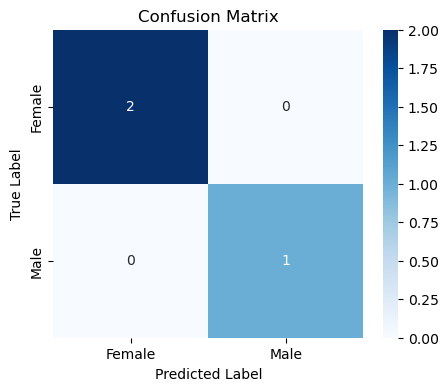

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### 6. Visualizing PCA Result:


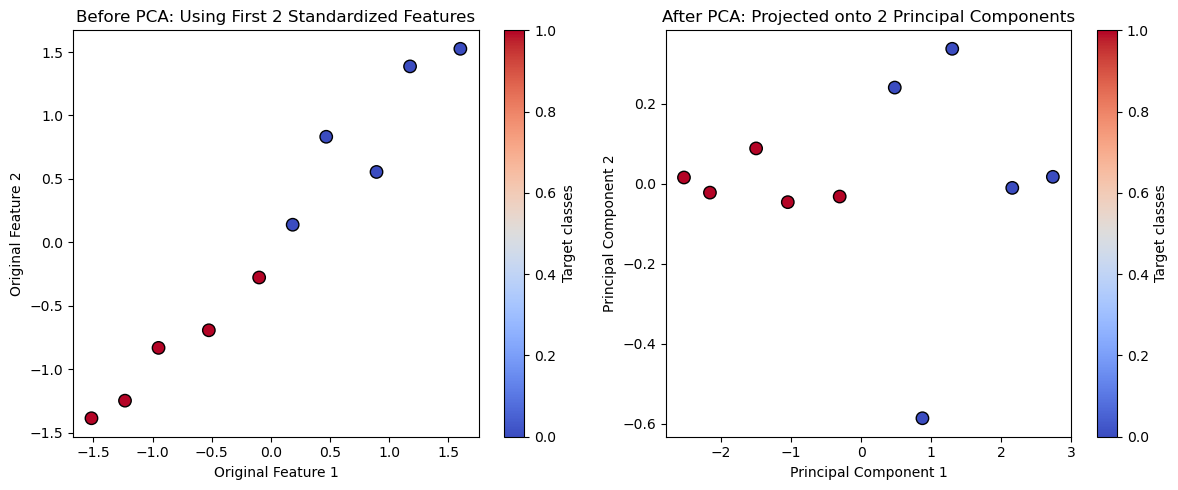

In [8]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

##### Left Plot Before PCA:
- This shows the original standardized data plotted using the first two features.
- There is no gurantee of clear seperation between classes as these are raw input dimensions.
##### Right Plot After PCA:
- This displays the transformed data using the top 2 principal components.
- These new components capture the maximum variance often showing better class seperation and structure making it easier to analyze or model.